# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

The objective of this project is to analyze customer and campaign data from a bank marketing datset to identify factor infulencing term deposit subscriptions. The Analysis aims to provide business insights and recommendations that can help the bank improve its marketing strategy and target the right customers more effectively.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Load the dataset
df = pd.read_csv(r"C:\Users\ATHAR\Downloads\pwskills\Internship Project\Bank Marketing Analysis\bankmarketing.csv")

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
df.shape

(41188, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [13]:
# Check for missing values and data types
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(12)

# Data Quality Check
- No missing values found in the dataset
- No duplicate records were identified.
- The dataset contains:
    - 11 Categorical columns
    - 10 numerical columns
      
This indicate that the dataset is clean and suitable for analysis

In [15]:
# Summary statistics
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Target Variable Analysis

In [16]:
# Traget variable
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [17]:
print(df['y'].value_counts(normalize=True) * 100)

# highly imbalance data showing 88.73 % No And 11.26% Yes


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


# Insights
- highly imbalance data showing 88.73 % No And 11.26% Yes
- due to highly imbalnce ML model will sbe baised and bank will miss potential customer who may actually subscribe(yes)



In [18]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [19]:
# Renaming the Target y to subscribe
df = df.rename(columns={'y':'Subscribe'})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Subscribe
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [20]:
# replacing the column and captalize the first letter
df = df.rename(columns=lambda x: x.replace('.', '_').capitalize())

In [21]:
df.head()

,Age,Job,Marital,Education,Default,Housing,Loan,Contact,Month,Day_of_week,...,Campaign,Pdays,Previous,Poutcome,Emp_var_rate,Cons_price_idx,Cons_conf_idx,Euribor3m,Nr_employed,Subscribe
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [22]:
# numerical column
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(list(numerical_cols))

Numerical Columns:
['Age', 'Duration', 'Campaign', 'Pdays', 'Previous', 'Emp_var_rate', 'Cons_price_idx', 'Cons_conf_idx', 'Euribor3m', 'Nr_employed']


In [23]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(list(categorical_cols))

Categorical Columns:
['Job', 'Marital', 'Education', 'Default', 'Housing', 'Loan', 'Contact', 'Month', 'Day_of_week', 'Poutcome', 'Subscribe']


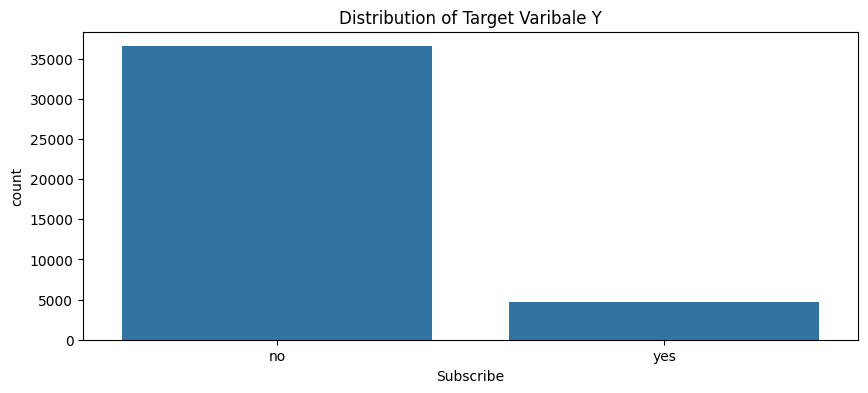

In [24]:
# Univarite Analysis
plt.figure(figsize=(10,4))
sns.countplot(x = 'Subscribe', data= df)
plt.title("Distribution of Target Varibale Y")
plt.show()

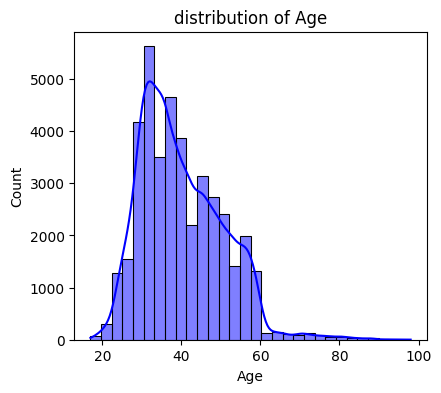

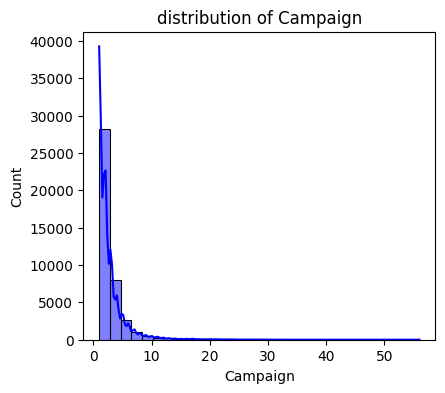

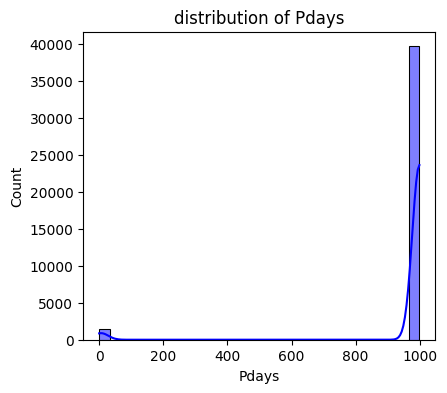

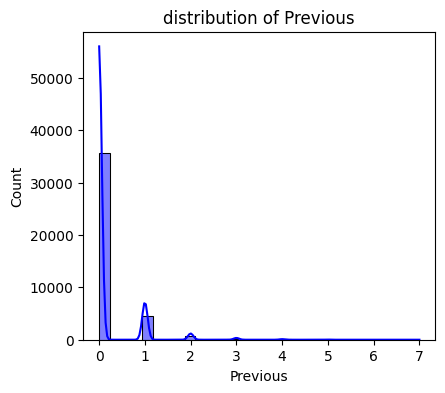

In [25]:
# univariate Anlysis on Numerical column
num_cols = ['Age', 'Campaign', 'Pdays', 'Previous']

for col in num_cols:
    plt.figure(figsize=(10,4))
        # hisplot to check data distribution
    plt.subplot(1,2,1)
    sns.histplot(df[col],bins=30, kde=True,color = "blue")  #bins = 30
    plt.title(f"distribution of {col}")

    # Boxplot fro oulier check
    # plt.subplot(1,2,2)
    # sns.boxplot(x=df[col], color = "lightblue")
    # plt.title(f"outlier in {col} ")
    # plt.tight_layout()
    plt.show()

    

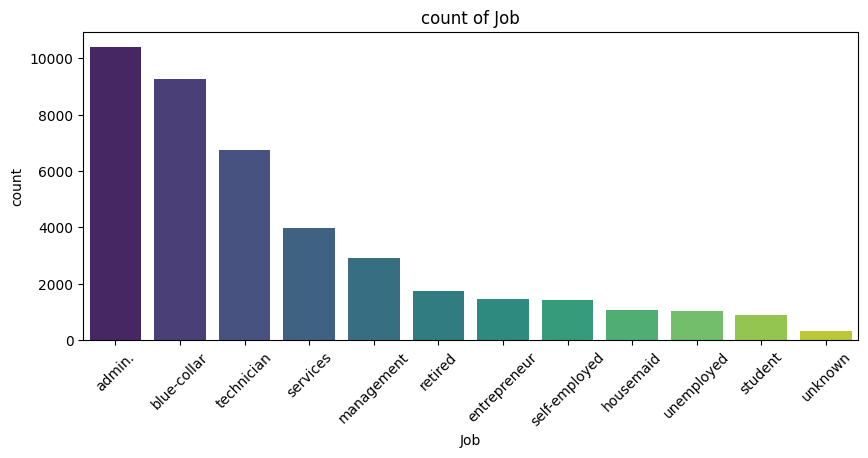

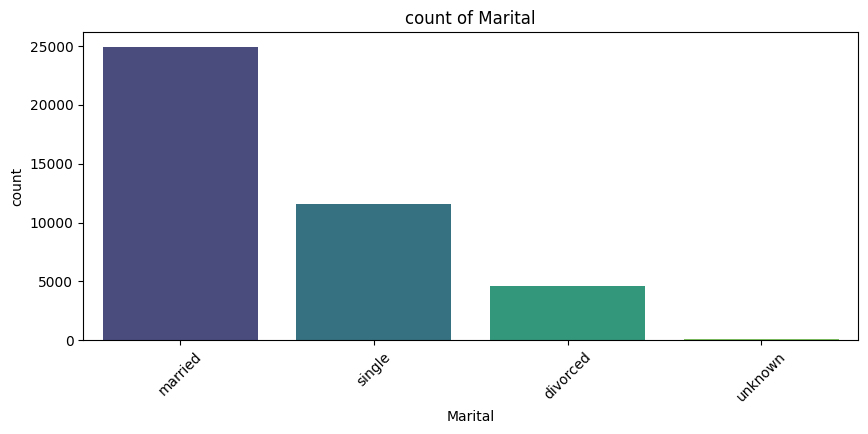

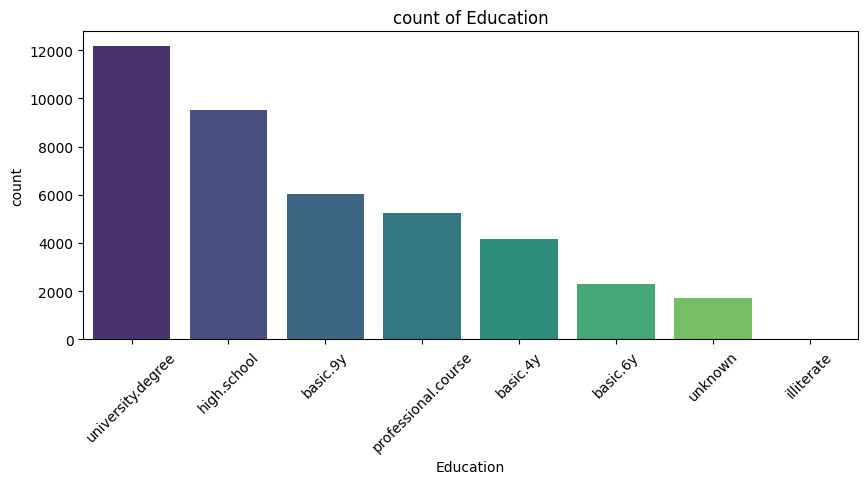

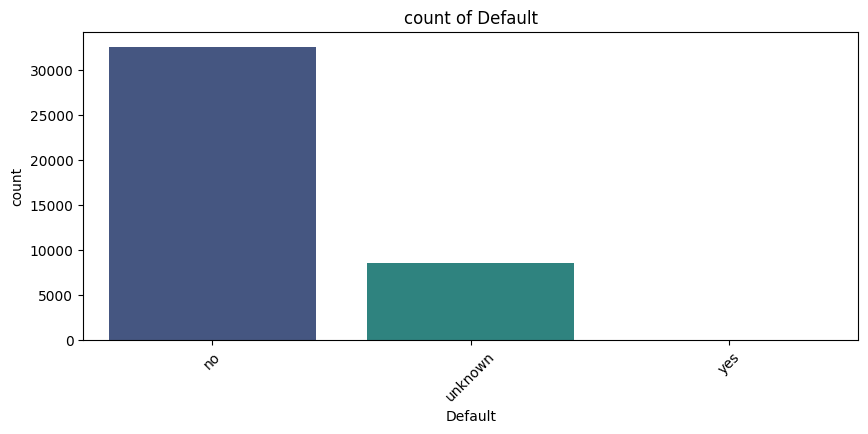

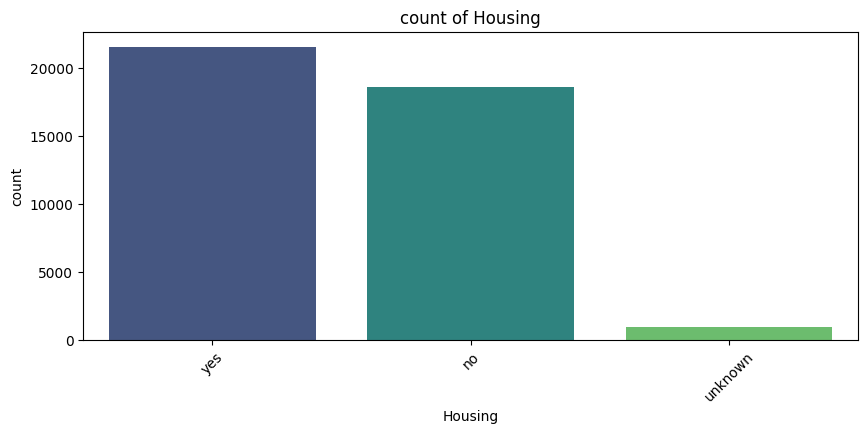

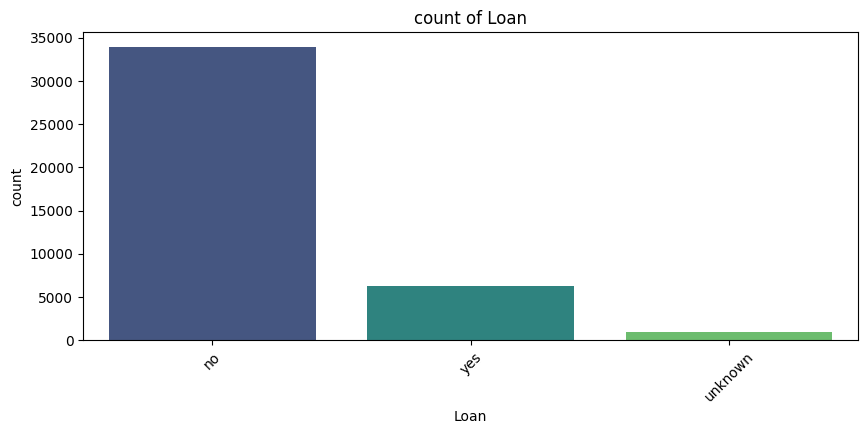

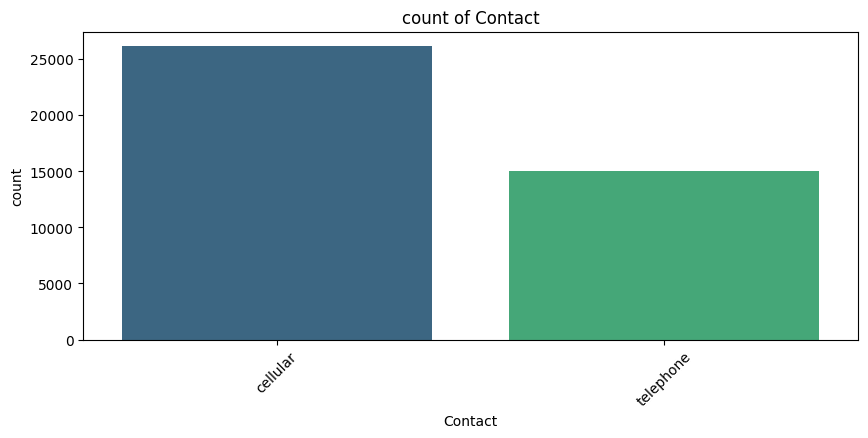

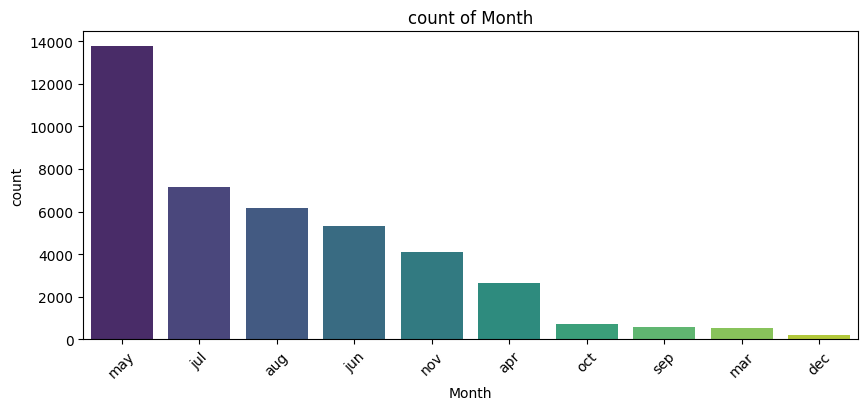

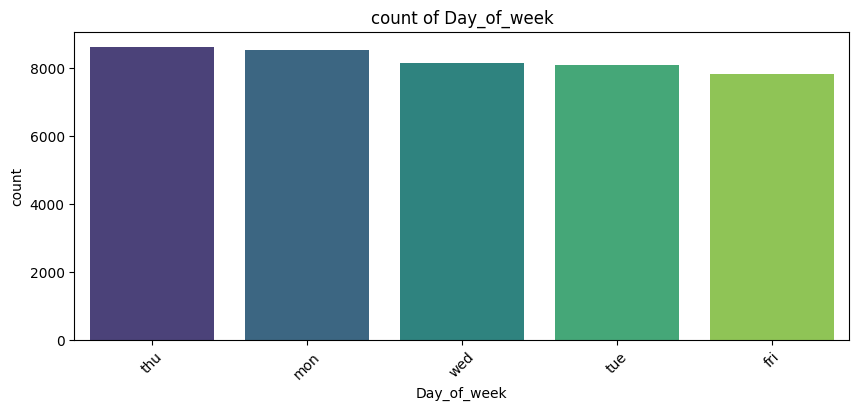

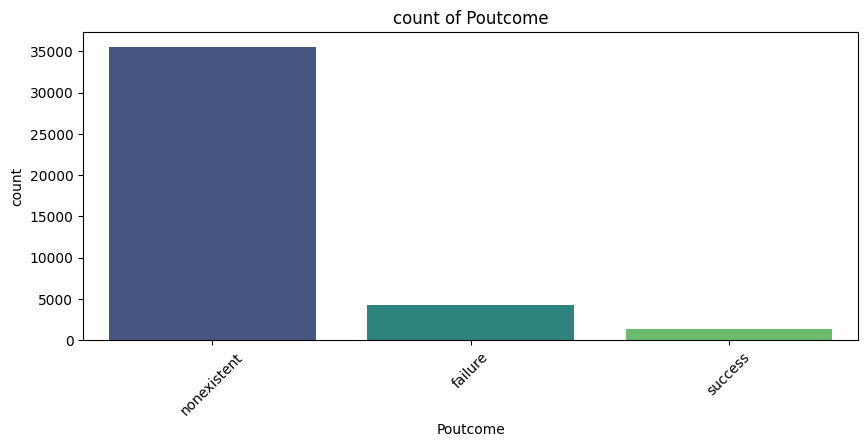

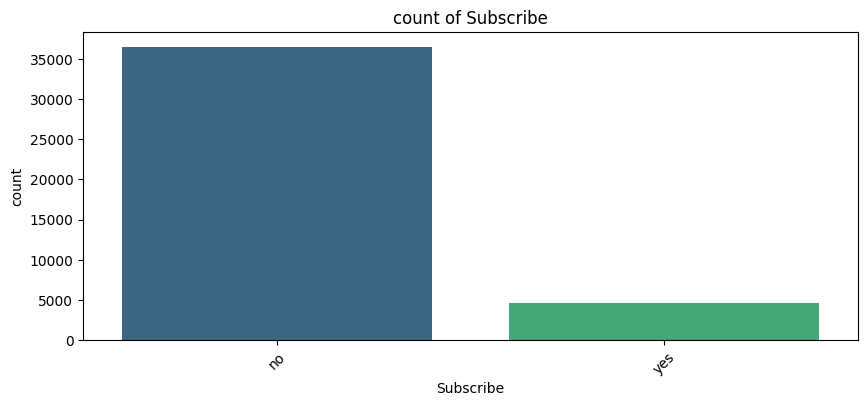

In [26]:
# univariate Analysis on categorical column
cat_cols = ['Job', 'Marital', 'Education', 'Default', 'Housing', 'Loan', 'Contact', 'Month', 'Day_of_week', 'Poutcome', 'Subscribe']
for col in cat_cols:
    plt.figure(figsize=(10,4))

    sns.countplot(data = df, x = df[col], palette ='viridis', order = df[col].value_counts().index)
    plt.title(f"count of {col}")
    plt.xticks(rotation = 45)
    plt.show()

In [27]:
# plt.figure(figsize=(8,5))
# sns.boxplot(x='Y', y='Age', data=df)
# plt.title('Age vs Subscription')
# plt.show()

In [28]:
# plt.figure(figsize=(8,5))
# sns.boxplot(x='Y', y='Age', data=df)
# plt.title('Age vs Subscription')
# plt.show()

In [29]:
# plt.figure(figsize=(12,5))
# sns.countplot(y='Education', hue='Y', data=df)
# plt.title('Education vs Subscription')
# plt.show()

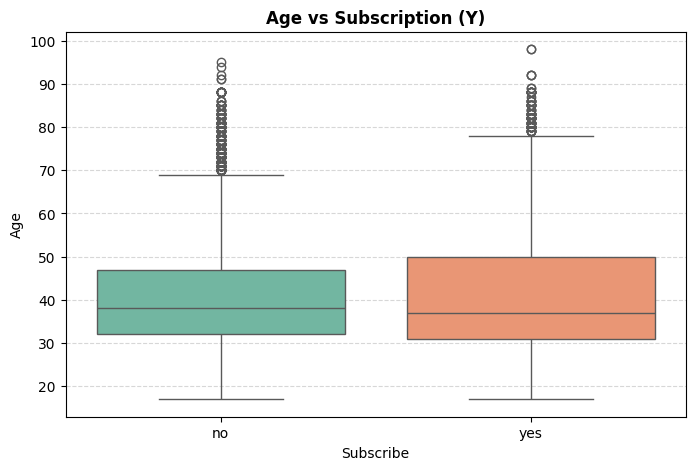

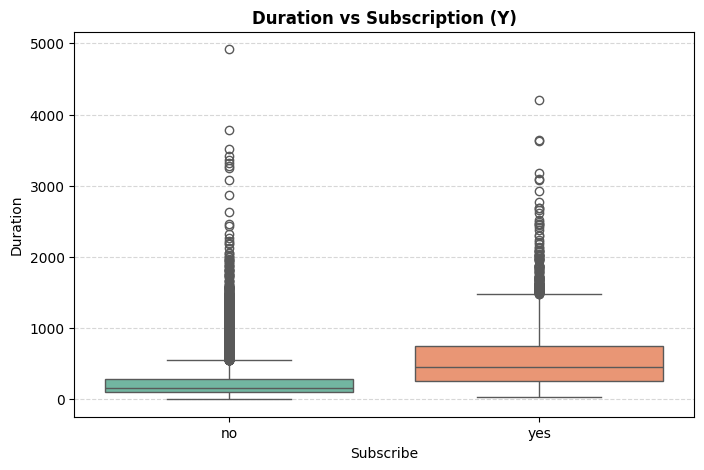

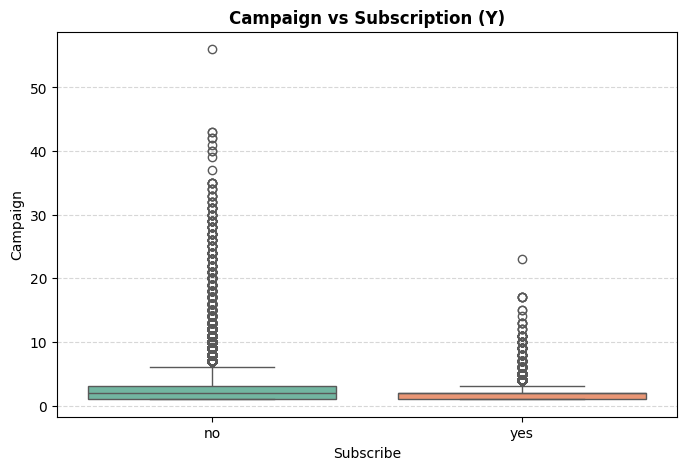

In [30]:
# Bivariate Analysis for numerical columns

num_cols = ['Age', 'Duration', 'Campaign']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    # 'Y' on the x-axis splits the boxplot into "yes" vs "no" groups
    sns.boxplot(x= 'Subscribe', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Subscription (Y)', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


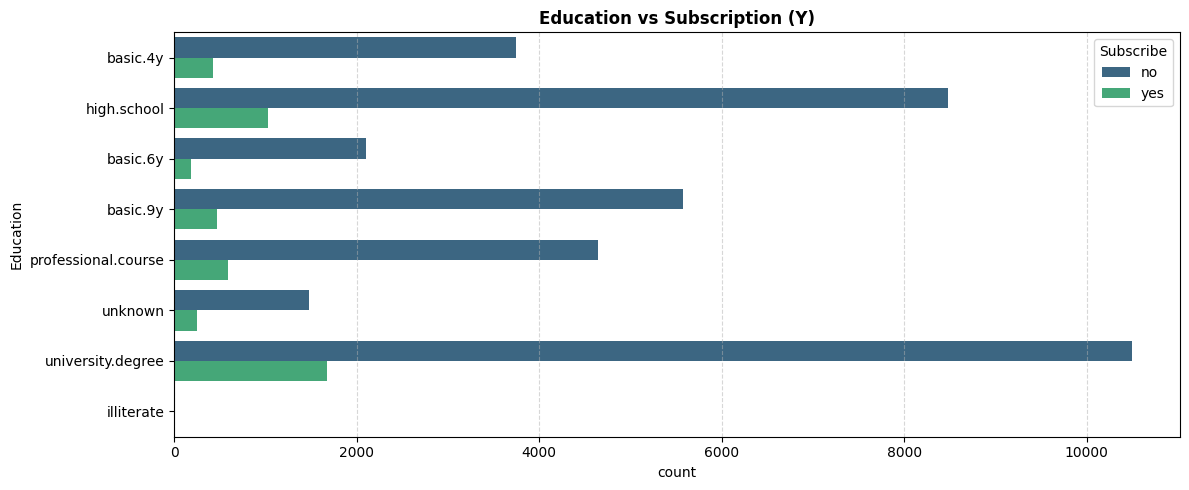

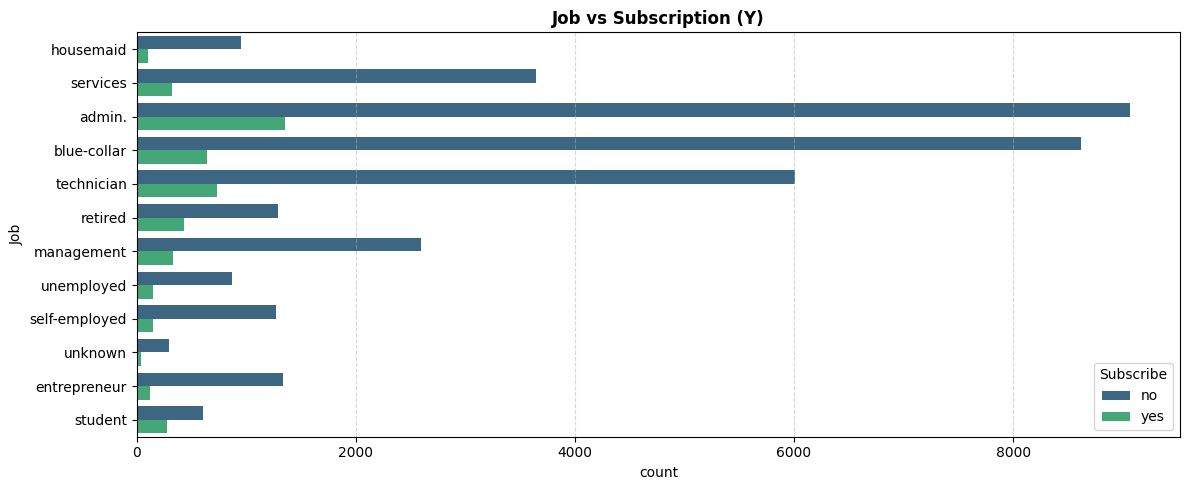

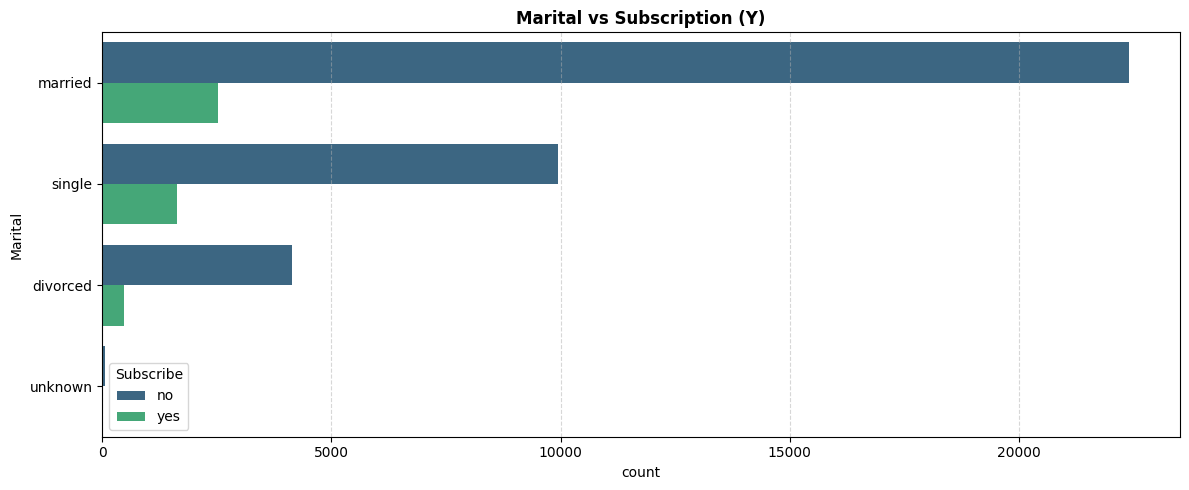

In [31]:
# Bivariate Analysis for categorical columns (excluding 'Y')

cat_cols = ['Education', 'Job', 'Marital']

for col in cat_cols:
    plt.figure(figsize=(12, 5))
    # Putting the column on 'y' makes the bars stretch horizontally
    sns.countplot(y=col, hue= 'Subscribe', data=df, palette='viridis') #order=df[col].value_counts().index)
    plt.title(f'{col} vs Subscription (Y)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Job Category Analysis

In [32]:
# Job Subscription Rate

job_sub = pd.crosstab(df['Job'], df['Subscribe'], normalize='index') * 100
job_sub.sort_values(by='yes', ascending=False)

Subscribe,no,yes
Job,,
student,68.571429,31.428571
retired,74.767442,25.232558
unemployed,85.798817,14.201183
admin.,87.027442,12.972558
management,88.782490,11.217510
unknown,88.787879,11.212121
technician,89.173958,10.826042
self-employed,89.514426,10.485574
housemaid,90.000000,10.000000


# Insights
The top job categories are:
- Admin
- Blue_collar
- Technician

  However, after analyzing subscription percentage:
  - Student showed the highest subscription rate(~31%)
  - Retired customer showed the second-Highest subscription rate(~25%)

    Insights:
    
    Although admin customer are highest in count, student and retired customer are more likely to subcribe, making them valuable target group.

# Education Analysis

In [33]:
# Education Subscription Rate

edu_sub = pd.crosstab(df['Education'], df['Subscribe'], normalize='index') * 100
edu_sub.sort_values(by='yes', ascending=False)

Subscribe,no,yes
Education,,
illiterate,77.777778,22.222222
unknown,85.499711,14.500289
university.degree,86.275477,13.724523
professional.course,88.651535,11.348465
high.school,89.164477,10.835523
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648


In [34]:
df['Education'].value_counts()

Education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

# Insights

Most customer have:
- University Degree
- High School Education

    Insights:

  Univeristy degree and high school educated customer provide more reliable customer segments due to large sample size.

Note :

  Although the illiterate category has the highest subscription percentage, the sample size is too small (only 18 customers), making it unreliable for business decisions. For practical targeting, customers with university degrees and high school education are more reliable segments due to their larger customer base.

# Loan & Financial Status Analysis

In [35]:
# Housing Loan vs Subscription

housing_sub = pd.crosstab(df['Housing'], df['Subscribe'], normalize='index') *100
housing_sub.sort_values(by='yes', ascending= False)

# Customers without housing loans show a slightly higher subscription rate compared to customers with housing loans.

Subscribe,no,yes
Housing,,
yes,88.380608,11.619392
no,89.120395,10.879605
unknown,89.191919,10.808081


In [36]:
# Personal Loan vs Subscription

personal_sub = pd.crosstab(df['Loan'], df['Subscribe'], normalize='index') * 100
personal_sub.sort_values(by='yes', ascending=False)

# Customers with personal loans are less likely to subscribe to term deposits, possibly because they already have financial obligations.

Subscribe,no,yes
Loan,,
no,88.659794,11.340206
yes,89.068502,10.931498
unknown,89.191919,10.808081


In [37]:
# Credit Default vs Subscription

credit_sub = pd.crosstab(df['Default'], df['Subscribe'], normalize='index') * 100
credit_sub.sort_values(by='yes', ascending=False)

# Customers with credit default history show almost no subscription, while customers without default have a higher subscription rate (~12%). This suggests financially stable customers are more likely to subscribe.

Subscribe,no,yes
Default,,
no,87.121026,12.878974
unknown,94.847040,5.152960
yes,100.000000,0.000000


# Insights
Housing Loan
- Customer without housing loan showed slightly better subscription behavior than customer with housing loan

Personal Loan
- Customer with personal loans were likely to subscribe to term deposits.

Insights

- Finacial obligation may reduce customers willingness to invest in addtional banking products

Credit Default
-  customer with default history showed almost no subscription, while customer without default had around 12% subscription rate.

 Insights

 - Financially stable customers are more likely to subscribe.

In [38]:
# contact vs Susbcription

contact_sub = pd.crosstab(df['Contact'], df['Subscribe'], normalize='index') * 100
contact_sub.sort_values(by='yes', ascending=False)

Subscribe,no,yes
Contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


# Contact method

The cellular contact method performed better than telephone

Insights:

customers contacted through cellular communication showed higher subscription rated.

In [39]:
# month-wise vs subscription
month_sub = pd.crosstab(df['Month'], df['Subscribe'], normalize='index') * 100
month_sub.sort_values(by='yes', ascending=False)

Subscribe,no,yes
Month,,
mar,49.450549,50.549451
dec,51.098901,48.901099
sep,55.087719,44.912281
oct,56.128134,43.871866
apr,79.521277,20.478723
aug,89.397863,10.602137
jun,89.488530,10.511470
nov,89.856133,10.143867
jul,90.953443,9.046557


# Month-wise Analysis

- March showed the highest subscription rate(~50%)
- December showed the second hoghest subscription rate(~45%)

Note:

These findings should be validated with sample size before making strong business decisions.



# Previous Campaign Outcome (poutcome)

In [40]:
# Previous Campaign Outcome 
poutcome_sub = pd.crosstab(df['Poutcome'], df['Subscribe'], normalize='index') * 100
print(poutcome_sub)

Subscribe           no        yes
Poutcome                         
failure      85.771402  14.228598
nonexistent  91.167787   8.832213
success      34.887109  65.112891


In [41]:
df['Poutcome'].value_counts()

Poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

# Insights

- Customers with successful previous campaign outcomes showed the highest subscription rate (~65%).
- Customers with previous campaign failure showed significantly lower subscription rates.

Insight:

- Previous successful customers are highly likely to subscribe again and should be prioritized.

# Correlation Analysis

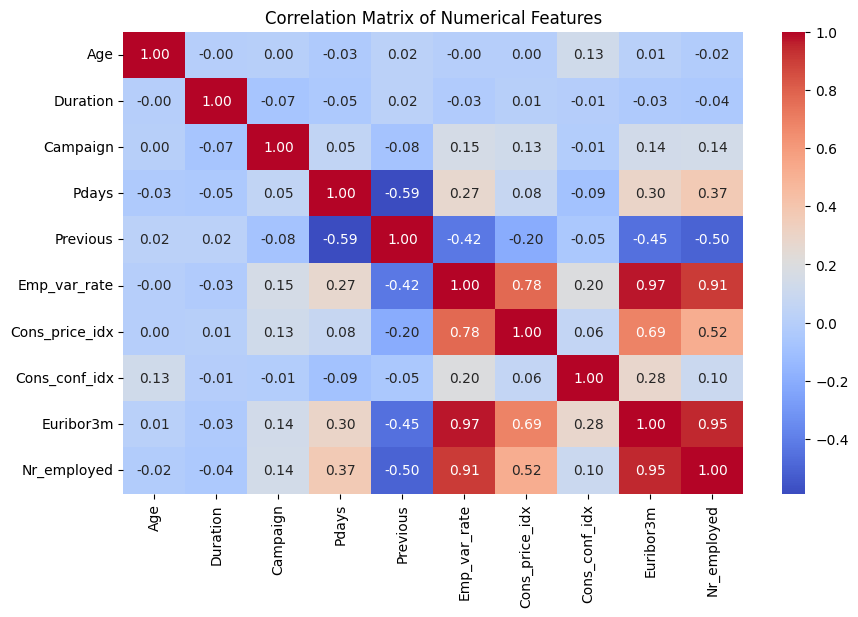

In [42]:
# Correlation matrix for numerical features

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()



# Insights
-The heatmap shows strong positive correlation among economic indicators such as emp_var_rate, euribor3m, and nr_employed, indicating possible multicollinearity. Additionally, pdays and previous show moderate negative correlation (-0.59). Most other numerical variables exhibit weak correlation, suggesting independent contribution to the dataset.

# Business Recommendations
Based on the analysis, the following recommendations are suggested:
 - Proritize cellular marketing campaigns over telephone communication due to better customer response 
- Target students and retired customers, as they show higher subscription rates.
- Focus on financially stable customers, especially those without personal loans or credit default history
 - Retraget customer with successful previous campaign outcomes, as they are more likely to subscribe again
 - plan campaigns strategically during high performing months, such as March and December, after validating customer volume.
 - Focus marketing efforts on university degree and high school educated customers, as they represnt larger and more reliable customer groups.



## Conclusion

The analysis identified several important factors affecting customer subscription behavior.

- Customer demographics, financial condition, contact methods, and previous campaign outcomes play a major role in determining subscription success
- The findings suggest that the bank can improve marketing efficiency by targeting high-conversion customer groups, otimizing communication methods, and using histrical campaign success to guide future campaigns.
